In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
from datetime import datetime, timedelta
import polars as pl

from thrs.control.modules.boilers import (
    BoilersControl,
    BoilersParameters,
    BoilersAlarms,
)
from thrs.input_output.base import Stamped
from thrs.input_output.modules.boilers import (
    BoilersControlValues,
    BoilersSensorValues,
    BoilersSimulationInputs,
    BoilersSimulationOutputs,
)
from thrs.input_output.definitions.simulation import (
    Boundary,
    HeatSource,
    OverpressureTemperatureBoundary,
    TemperatureBoundary,
)
from thrs.orchestration.simulator import Simulator, SimulatorModel
from thrs.simulation.models.fmu_paths import boilers_path

start_time = datetime.fromtimestamp(0)
duration = timedelta(minutes=30)
time_index = pl.datetime_range(
    start_time, start_time + duration, interval="1m", time_unit="us", eager=True
)

simulation_inputs = BoilersSimulationInputs(
    boilers_lt1_supply=Boundary(temperature=Stamped.stamp(40), flow=Stamped.stamp(35)),
    boilers_lt2_supply=Boundary(temperature=Stamped.stamp(60), flow=Stamped.stamp(60)),
    boilers_fahrenheit_supply=Boundary(
        temperature=Stamped.stamp(30), flow=Stamped.stamp(45)
    ),
    boilers_ht_supply=Boundary(temperature=Stamped.stamp(70), flow=Stamped.stamp(29)),
    boilers_freshwater_supply=OverpressureTemperatureBoundary(
        temperature=Stamped.stamp(20), overpressure=Stamped.stamp(0.5)
    ),
    boilers_exchanger_gas=HeatSource(heat_flow=Stamped.stamp(0)),
    boilers_seawater_supply=TemperatureBoundary(temperature=Stamped.stamp(20)),
)


boilers_model = SimulatorModel(
    fmu_path=boilers_path,
    sensor_values_cls=BoilersSensorValues,
    control_values_cls=BoilersControlValues,
    simulation_outputs_cls=BoilersSimulationOutputs,
    simulation_inputs=simulation_inputs,
    control_cls=BoilersControl,
    control_parameters=BoilersParameters(),
    alarms=BoilersAlarms(),
    tick_duration=timedelta(seconds=1),
    start_time=start_time,
)

with boilers_model.executor() as executor:
    simulation = Simulator.from_model(boilers_model, executor)
    result = await simulation.run(int(duration.total_seconds()))

[WARNING] State logging: Please enable result storing to get state names


/Users/alje/Repos/zero/zero-thrs-control/analysis/analysis_utils.py:407: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


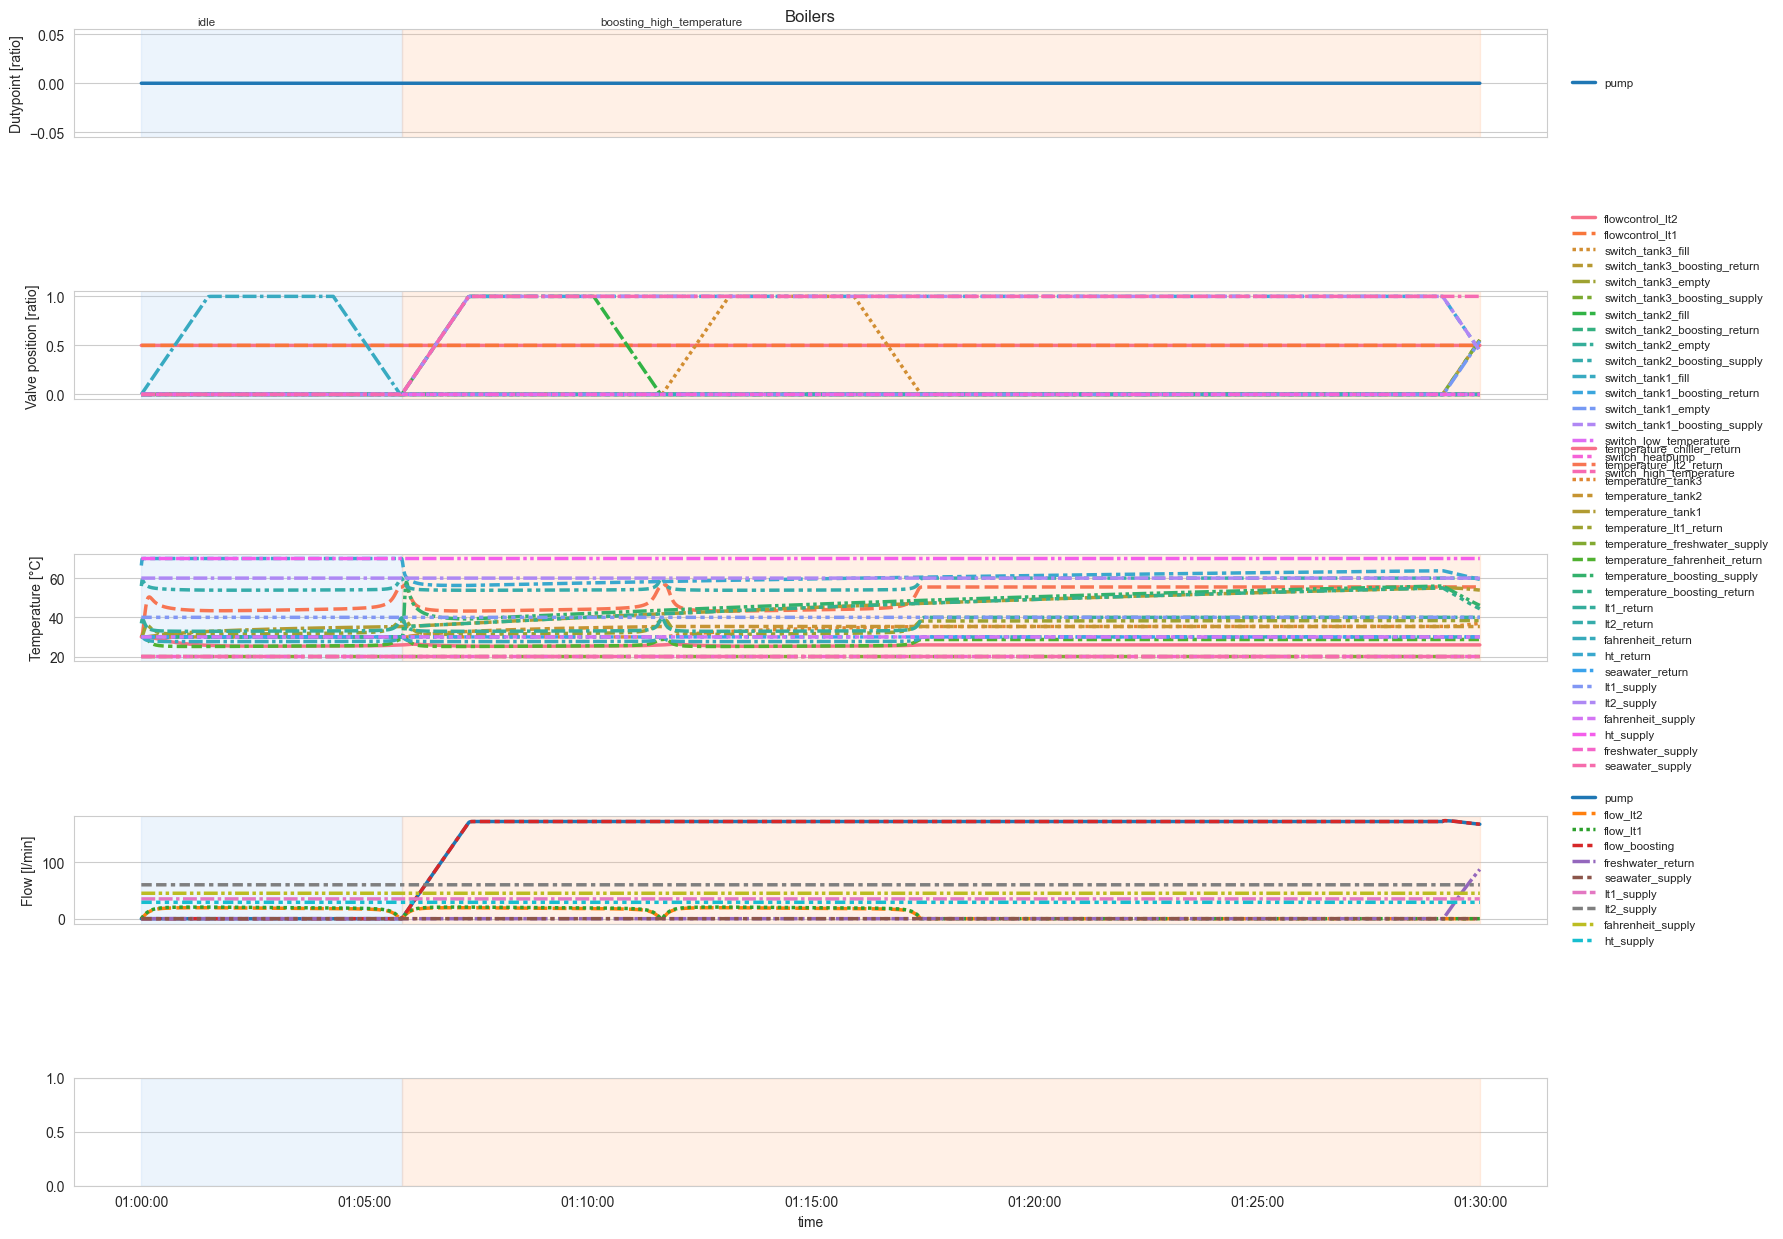

In [41]:
from analysis.analysis_utils import plot_result

plot_result(result, "plots/boilers.png");

<Axes: >

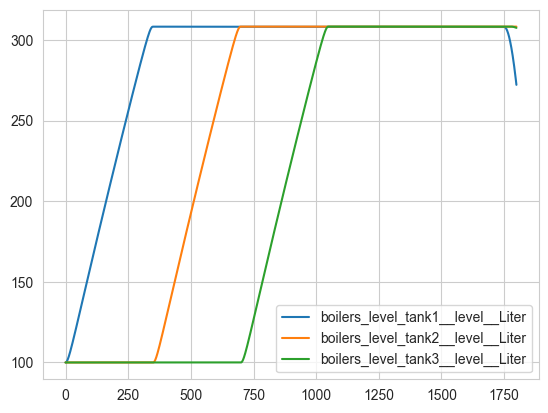

In [42]:
result[[x for x in result.columns if "level" in x]].to_pandas().plot()

<Axes: >

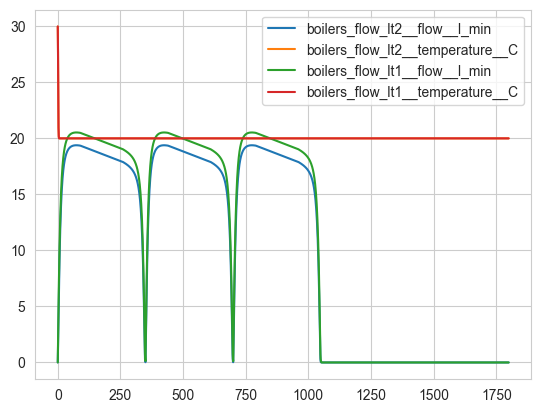

In [43]:
result[[x for x in result.columns if "flow_lt" in x]].to_pandas().plot()

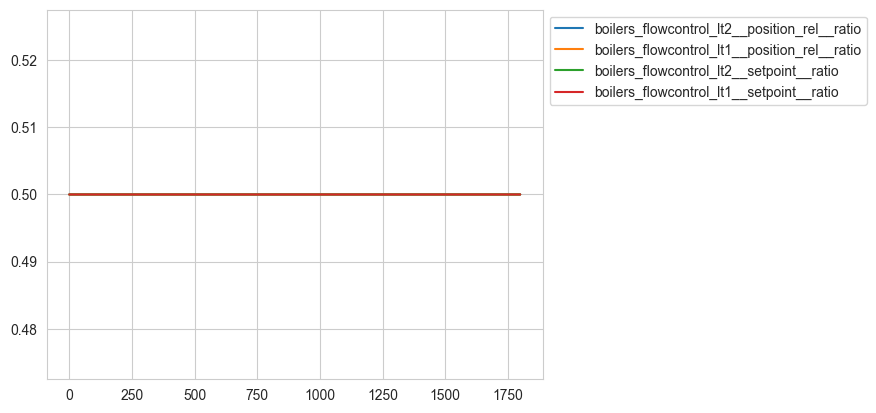

In [44]:
ax = result[[x for x in result.columns if "flowcontrol" in x]].to_pandas().plot()
ax.legend(loc="upper left").set_bbox_to_anchor((1, 1))

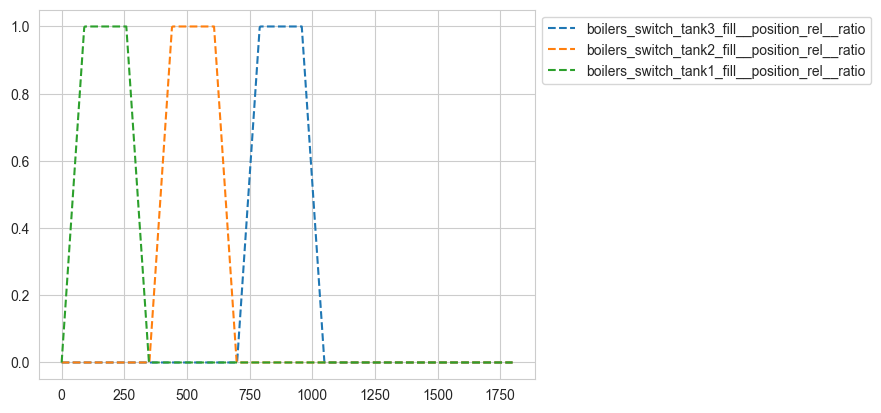

In [45]:
ax = (
    result[[x for x in result.columns if ("fill__position" in x)]]
    .to_pandas()
    .plot(ls="--")
)
ax.legend(loc="upper left").set_bbox_to_anchor((1, 1))

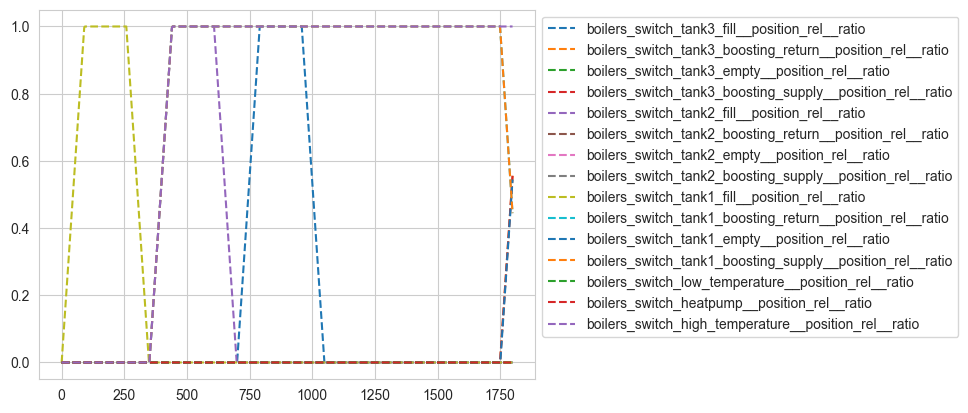

In [46]:
ax = (
    result[[x for x in result.columns if ("switch" in x) and ("position" in x)]]
    .to_pandas()
    .plot(ls="--")
)
ax.legend(loc="upper left").set_bbox_to_anchor((1, 1))

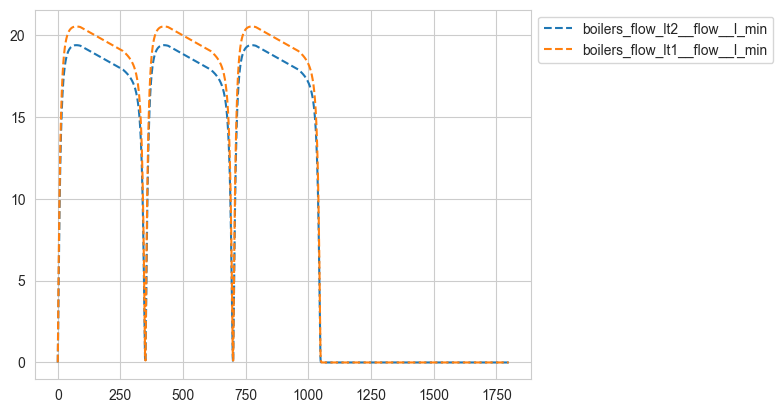

In [47]:
ax = (
    result[
        [
            x
            for x in result.columns
            if ("flow_lt1__flow" in x) or ("flow_lt2__flow" in x)
        ]
    ]
    .to_pandas()
    .plot(ls="--")
)
ax.legend(loc="upper left").set_bbox_to_anchor((1, 1))

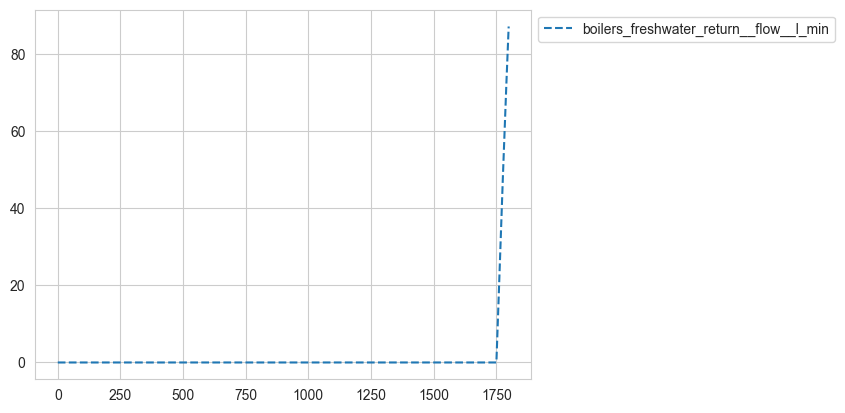

In [48]:
ax = (
    result[[x for x in result.columns if ("freshwater_return" in x)]]
    .to_pandas()
    .plot(ls="--")
)
ax.legend(loc="upper left").set_bbox_to_anchor((1, 1))

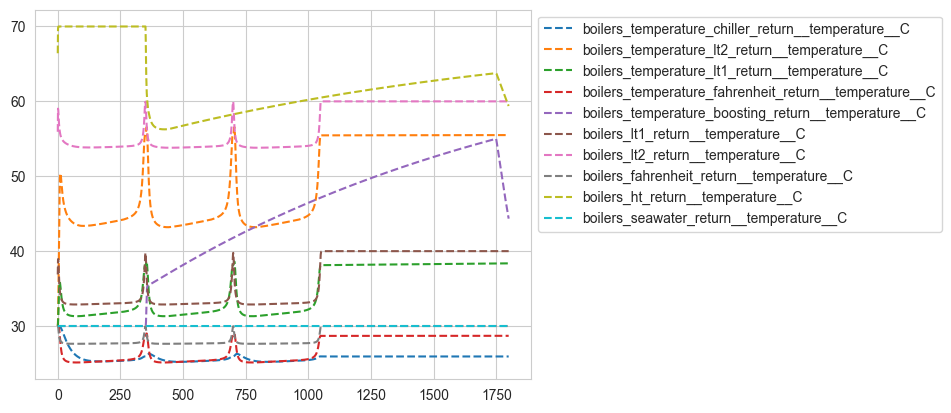

In [49]:
ax = (
    result[[x for x in result.columns if "return__temperature" in x]]
    .to_pandas()
    .plot(ls="--")
)
ax.legend(loc="upper left").set_bbox_to_anchor((1, 1))

<Axes: >

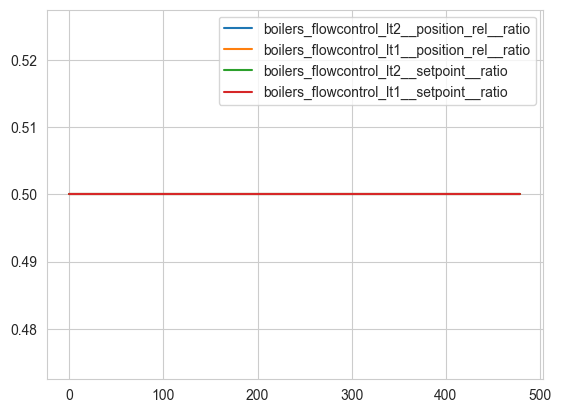

In [16]:
result[[x for x in result.columns if "flowcontrol" in x]].to_pandas().plot()

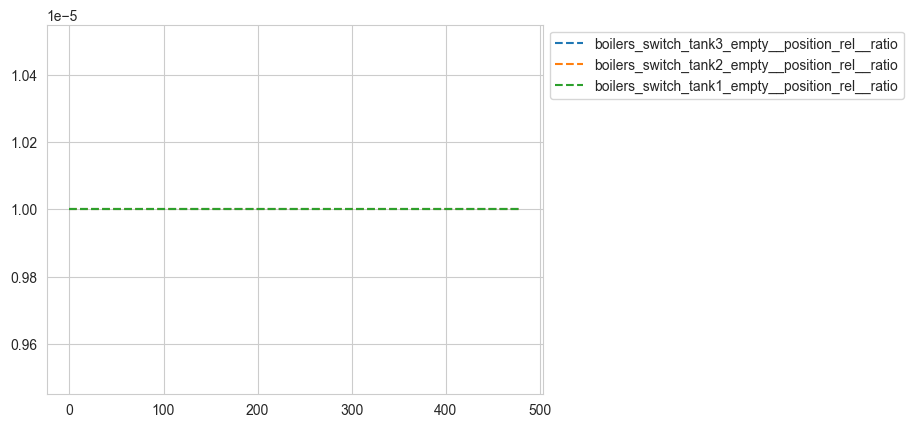

In [17]:
ax = (
    result[[x for x in result.columns if ("empty__position" in x)]]
    .to_pandas()
    .plot(ls="--")
)
ax.legend(loc="upper left").set_bbox_to_anchor((1, 1))

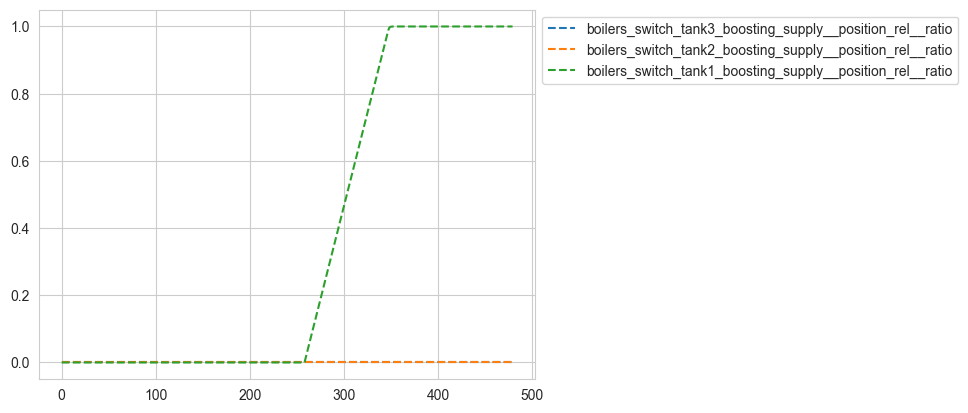

In [19]:
ax = (
    result[[x for x in result.columns if ("supply__position" in x)]]
    .to_pandas()
    .plot(ls="--")
)
ax.legend(loc="upper left").set_bbox_to_anchor((1, 1))

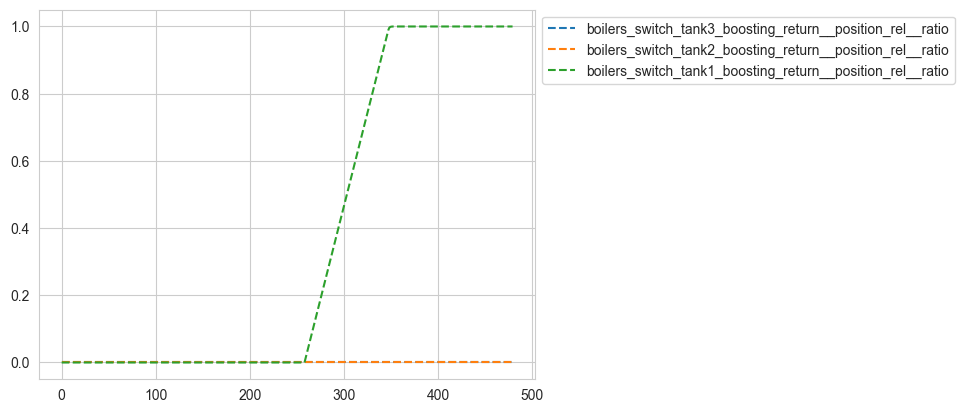

In [20]:
ax = (
    result[[x for x in result.columns if ("return__position" in x)]]
    .to_pandas()
    .plot(ls="--")
)
ax.legend(loc="upper left").set_bbox_to_anchor((1, 1))

In [ ]:
from transitions.extensions import GraphMachine

control = BoilersControl(BoilersParameters(), time_fn=datetime.now)
# without further arguments pygraphviz will be used
machine = GraphMachine(
    model=control,
    states=control._states,
    transitions=control._transitions,
    graph_engine="pygraphviz",
    initial="idle",
    show_conditions=True,
    show_state_attributes=True,
)

# draw the whole graph ...
control.get_graph().draw("plots/boilers_state_diagram.png", prog="dot")